In [21]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

from dotenv import load_dotenv

load_dotenv()

True

In [70]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [71]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [72]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str

In [73]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [74]:
def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    
    return {"plan": plan}

In [75]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [76]:
def worker(payload: dict) -> dict:
    
    # payload contains what we sent
    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']
    
    
    blog_title = plan.blog_title
    
    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f'Blog: {blog_title}\n'
                    f'Topic: {topic}\n\n'
                    f'Section: {task.title}\n'
                    f'Brief: {task.brief}\n\n'
                    'Return only the section content in Markdown.'
                )
            ),
        ]
    ).content.strip()
    
    return {"sections": [section_md]}



In [82]:
from pathlib import Path

root_path = Path.cwd().parent
destination_path = root_path / "generated_blogs"

# Ensure directory exists
destination_path.mkdir(parents=True, exist_ok=True)


def reducer(state: State) -> dict:

    title = state["plan"].blog_title
    
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # Save to file
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"

    output_path = destination_path / filename

    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [83]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

In [84]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)


app = g.compile()

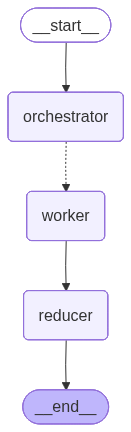

In [80]:
app

In [85]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})
out

c:\Users\soura\OneDrive\Desktop\blog_generator\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(blog_title='Understa... their applications.')]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: The Core of Modern Neural Networks', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain what self-attention is and why it is important in machine learning models, especially in natural language processing.'), Task(id=2, title='How Self-Attention Works', brief='Describe the mechanism of self-attention including queries, keys, and values, and how attention scores are calculated.'), Task(id=3, title='Self-Attention vs. Traditional Attention Mechanisms', brief='Compare self-attention with traditional attention mechanisms highlighting the advantages and differences.'), Task(id=4, title='Applications of Self-Attention', brief='Discuss real-world applications of self-attention in models like Transformers for tasks such as language modeling, translation, and more.'), Task(id=5, title='Benefits and Challenges of Using Self-Attention', brief='Outline the benefits of self-atte